
h = 0.01 | Total accumulated error: 0.000000
       x |    y_euler |      y_ref |  point_error
   0.000 |   1.000000 |   1.000000 |     0.000000
   0.010 |   0.980000 |   0.980000 |     0.000000
   0.020 |   0.960400 |   0.960400 |     0.000000
   0.030 |   0.941192 |   0.941192 |     0.000000
   0.040 |   0.922368 |   0.922368 |     0.000000
   0.050 |   0.903921 |   0.903921 |     0.000000
   0.060 |   0.885842 |   0.885842 |     0.000000
   0.070 |   0.868126 |   0.868126 |     0.000000
   0.080 |   0.850763 |   0.850763 |     0.000000
   0.090 |   0.833748 |   0.833748 |     0.000000
   0.100 |   0.817073 |   0.817073 |     0.000000
   0.110 |   0.800731 |   0.800731 |     0.000000
   0.120 |   0.784717 |   0.784717 |     0.000000
   0.130 |   0.769022 |   0.769022 |     0.000000
   0.140 |   0.753642 |   0.753642 |     0.000000
   0.150 |   0.738569 |   0.738569 |     0.000000
   0.160 |   0.723798 |   0.723798 |     0.000000
   0.170 |   0.709322 |   0.709322 |     0.000000
   0

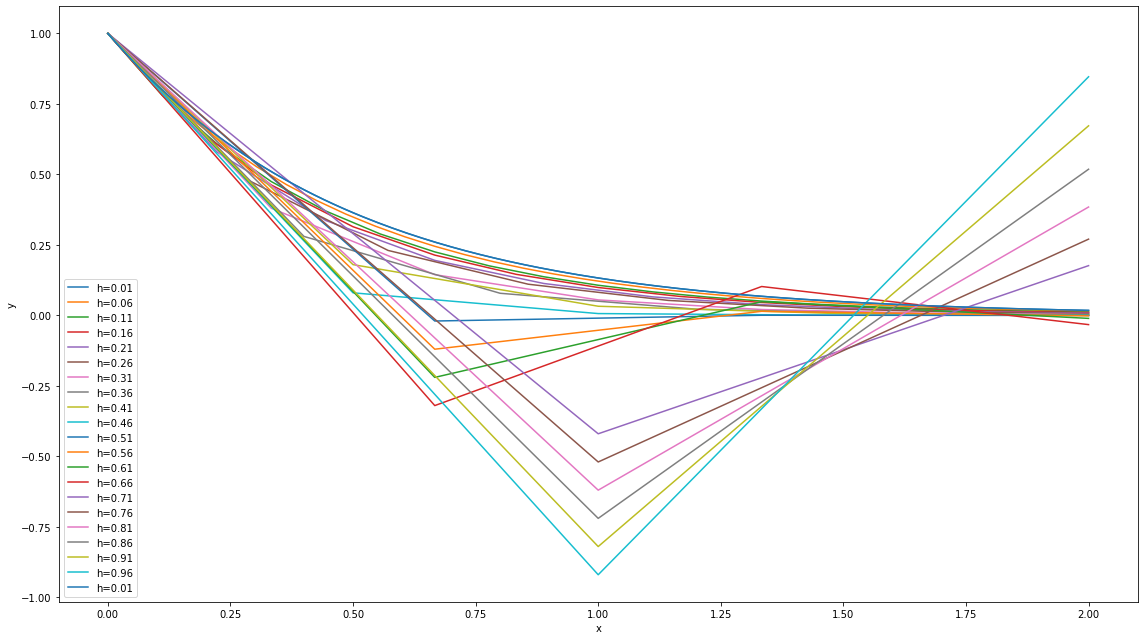

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return -2 * y

x_start, x_end = 0, 2
step_sizes = np.arange(0.01, 1.01, 0.05)

h_ref = step_sizes[0]
n_ref = int((x_end - x_start) / h_ref)
x_ref = np.linspace(x_start, x_end, n_ref + 1)
y_ref = np.zeros(n_ref + 1)
y_ref[0] = 1

for i in range(n_ref):
    y_ref[i + 1] = y_ref[i] + h_ref * f(x_ref[i], y_ref[i])

plt.figure(figsize=(16, 9))

for h in step_sizes:
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)
    y_values[0] = 1

    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    y_ref_interp = np.interp(x_values, x_ref, y_ref)
    point_errors = np.abs(y_values - y_ref_interp)
    total_error = np.sum(point_errors)

    print(f"\nh = {h:.2f} | Total accumulated error: {total_error:.6f}")
    print(f"  {'x':>6} | {'y_euler':>10} | {'y_ref':>10} | {'point_error':>12}")
    for j in range(len(x_values)):
        print(f"  {x_values[j]:>6.3f} | {y_values[j]:>10.6f} | {y_ref_interp[j]:>10.6f} | {point_errors[j]:>12.6f}")

    plt.plot(x_values, y_values, label=f"h={h:.2f}")

# Plot reference
plt.plot(x_ref, y_ref, label="h=0.01")
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.tight_layout()
plt.show()